# Student Performance Prediction Using Machine Learning
## A Comparative Study of Linear, Tree-Based, and Neural Network Models on the OULAD Dataset

- CS 627: Artificial Intelligence
- Dataset: Open University Learning Analytics Dataset (OULAD)
    - `https://archive.ics.uci.edu/dataset/349/open+university+learning+analytics+dataset`

### Objective

Using demographic and assessment data from ~30,000 students, we train and compare three machine learning models to predict whether a student will pass or fail their course:

1. Logistic Regression - linear baseline model
2. XGBoost - gradient boosted decision tree
3. Neural Network (MLP) - multilayer perceptron

Models are evaluated using accuracy, precision, recall, and F1-score to determine which best fits the data.

### Section 01: Imports

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

### Section 02: Data Loading

Two CSV files from the OULAD dataset are loaded:

1. `studentInfo.csv`
    - One row per student.
    - Contains demographic features (gender, region, age band, education level, disability, studied credits) and the final course outcome.
2. `studentAssessment.csv`
    - One row per submission.
    - A student who submitted multiple assessments will have multiple rows in this file.

In [63]:
# mapping '?' entries to NaN, since the dataset uses '?' to represent missing values
info = pd.read_csv("studentInfo.csv", na_values="?")
assess = pd.read_csv("studentAssessment.csv", na_values="?")

In [64]:
info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [65]:
assess.head()

,id_assessment,id_student,date_submitted,is_banked,score
0,1752,11391,18,0,78.0
1,1752,28400,22,0,70.0
2,1752,31604,17,0,72.0
3,1752,32885,26,0,69.0
4,1752,38053,19,0,79.0


In [66]:
print(info.shape)
print(assess.shape)

(32593, 12)
(173912, 5)


### Section 03: Data Cleaning

Score values are coerced to numeric type to handle any non-numeric entries in the raw file. Rows where the score is still missing after conversion are dropped, as they provide no usable signal.

In [67]:
# convert values in scores column into numbers, if the value is other than number (e.g. N/A or ?), put NaN instead
assess['score'] = pd.to_numeric(assess['score'], errors='coerce')

# delete any row where the score column is NaN
assess = assess.dropna(subset=['score'])

In [68]:
print(assess.shape)

(173739, 5)


### Section 04: Target Variable Contruction

The `final_result` column contains four values:
- Pass
- Distinction
- Fail
- Withdrawn

These are mapped to a bianry column 'passed':
- Pass or Distinction: 1 (student passed)
- Fail or Withdrawn: 0 (student did not pass)

Binary labels are requried for the classification metrics used in this study (accuracy, precision, recall, F1-score)

In [69]:
info['passed'] = info['final_result'].map({
    'Pass': 1,
    'Distinction': 1,
    'Fail': 0,
    'Withdrawn': 0,
})

In [70]:
# Drop rows where final_result did not match any expected category
info = info.dropna(subset=['passed'])

In [71]:
# Convert float to int after mapping
info['passed'] = info['passed'].astype(int)

In [72]:
# Print how many students passed and how many of them failed.
pass_counts = info['passed'].value_counts()
print(f"Pass (1): {pass_counts[1]} students ({pass_counts[1]/len(info)*100:.1f}%)")
print(f"Fail (0): {pass_counts[0]} students ({pass_counts[0]/len(info)*100:.1f}%)")

Pass (1): 15385 students (47.2%)
Fail (0): 17208 students (52.8%)


### Section 05: Feature Engineering

Since the assessment file has multiple rows per student, we aggregate them into a single row per student using three summary statistics:

- `avg_score`
    - Mean score across all submitted assessments.
    - Represents overall academic performance.
- `score_std`
    - Standard deviation of scores across assessments.
    - Captures how consistent the student's performance was.
- `num_assessments`
    - Total number of assessments submitted.
    - Serves as a proxy for student engagement.
 
Students with only one submission have no standard deviation so, `score_std` is filled with 0 in those cases.

In [73]:
student_features = assess.groupby('id_student').agg(
    avg_score = ('score', 'mean'),
    score_std = ('score', 'std'),
    num_assessments = ('score', 'count')
).reset_index()

In [74]:
student_features['score_std'] = student_features['score_std'].fillna(0)

### Section 06: Merging Datasets
We merge the student demographic data (info) with the assessment summary (student_features) using an inner join on `id_student`, so that each student has a single unified row containing both their profile information and their aggregated assessment statistics.

In [75]:
df = pd.merge(info, student_features, on='id_student', how='inner')
df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,passed,avg_score,score_std,num_assessments
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,1,82.0,3.082207,5
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1,66.4,4.335897,5
2,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,1,76.0,6.892024,5
3,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1,54.4,20.513410,5
4,AAA,2013J,38053,M,Wales,A Level or Equivalent,80-90%,35-55,0,60,N,Pass,1,68.0,10.977249,5


In [76]:
df.shape

(26727, 16)

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26727 entries, 0 to 26726
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           26727 non-null  object 
 1   code_presentation     26727 non-null  object 
 2   id_student            26727 non-null  int64  
 3   gender                26727 non-null  object 
 4   region                26727 non-null  object 
 5   highest_education     26727 non-null  object 
 6   imd_band              25714 non-null  object 
 7   age_band              26727 non-null  object 
 8   num_of_prev_attempts  26727 non-null  int64  
 9   studied_credits       26727 non-null  int64  
 10  disability            26727 non-null  object 
 11  final_result          26727 non-null  object 
 12  passed                26727 non-null  int32  
 13  avg_score             26727 non-null  float64
 14  score_std             26727 non-null  float64
 15  num_assessments    

In [78]:
df['num_assessments'].min()

1

In [79]:
df['num_assessments'].max()

28

In [80]:
df['studied_credits'].min()

30

In [81]:
df['studied_credits'].max()

630

### Section 07: Exploratory Data Analysis (EDA)

Three charts are produced to understand the dataset before modeling:

#### Chart 01: Pass vs. Fail Count
- How many students passed vs. failed?
- A bar chart:
  - red bar = failed
  - green bar = passed

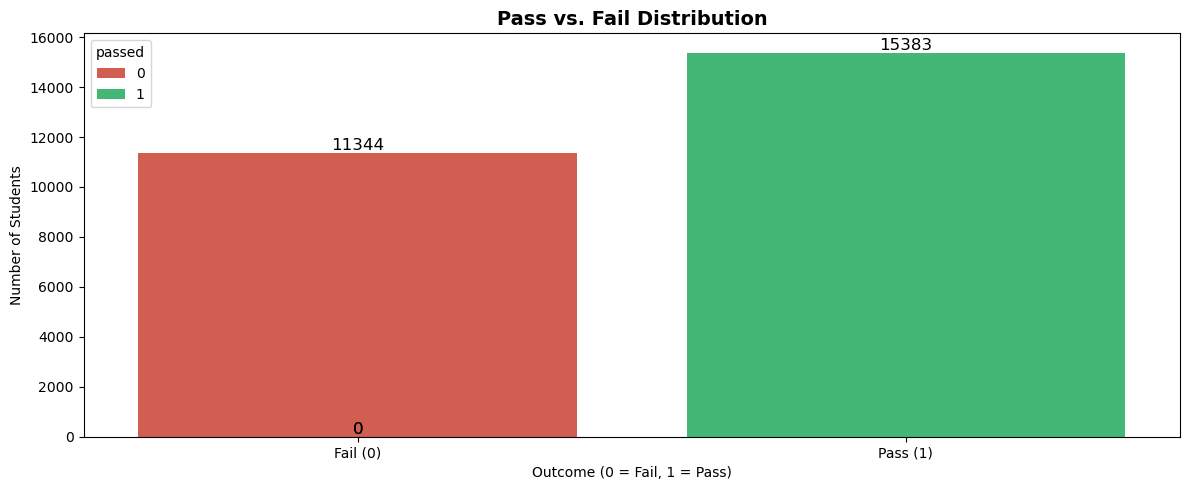

In [82]:
# Chart 1: Pass vs. Fail Distribution
fig1, ax1 = plt.subplots(figsize=(12, 5))
sns.countplot(x='passed', data=df, hue='passed', palette=['#e74c3c', '#2ecc71'], ax=ax1)
ax1.set_title('Pass vs. Fail Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Outcome (0 = Fail, 1 = Pass)')
ax1.set_ylabel('Number of Students')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Fail (0)', 'Pass (1)'])
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=12)
plt.tight_layout()
plt.show()

#### Chart 02: Average Score
- Do students who pass score higher on average?
- Two overlapping histograms - one for students who passed and one for students who failed
- If the two histograms overlap a lot, scores alone do not tell us much
- If they are far apart, scores are a strong predictor


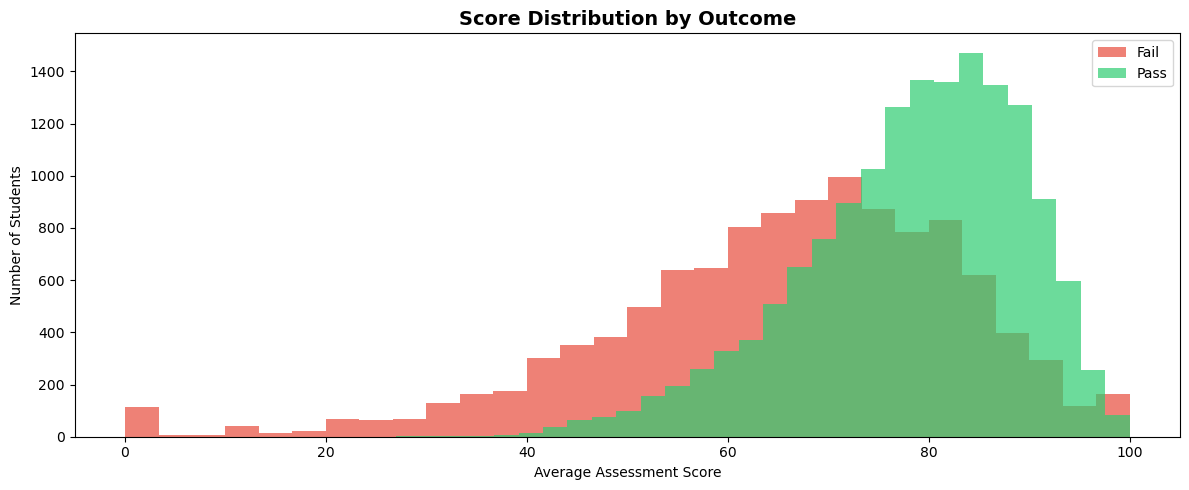

In [83]:
# Chart 2: Score Distribution by Outcome
fig2, ax2 = plt.subplots(figsize=(12, 5))
fail_scores = df[df['passed'] == 0]['avg_score']
pass_scores = df[df['passed'] == 1]['avg_score']
ax2.hist(fail_scores, bins=30, alpha=0.7, color='#e74c3c', label='Fail')
ax2.hist(pass_scores, bins=30, alpha=0.7, color='#2ecc71', label='Pass')
ax2.set_title('Score Distribution by Outcome', fontsize=14, fontweight='bold')
ax2.set_xlabel('Average Assessment Score')
ax2.set_ylabel('Number of Students')
ax2.legend()
plt.tight_layout()
plt.show()

#### Chart 03: Credits vs Pass Rate
- Does taking more credits affect passing?
- Grouping students by how many credits they studied, then calculating pass rate for each group.

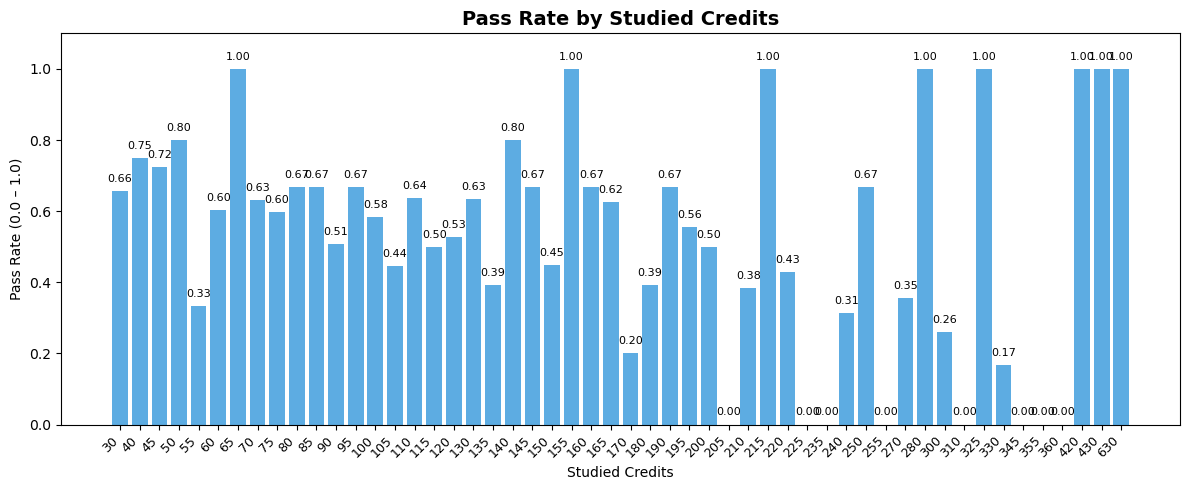

In [84]:
# Chart 3: Pass Rate by Studied Credits
fig3, ax3 = plt.subplots(figsize=(12, 5))
credit_pass = df.groupby('studied_credits')['passed'].mean().reset_index()
credit_pass = credit_pass.sort_values('studied_credits')

ax3.bar(range(len(credit_pass)), credit_pass['passed'], color='#3498db', alpha=0.8)
ax3.set_title('Pass Rate by Studied Credits', fontsize=14, fontweight='bold')
ax3.set_xlabel('Studied Credits')
ax3.set_ylabel('Pass Rate (0.0 – 1.0)')
ax3.set_ylim(0, 1.1)
ax3.set_xticks(range(len(credit_pass)))
ax3.set_xticklabels(credit_pass['studied_credits'].astype(int), rotation=45, ha='right', fontsize=9)
for i, (bar, val) in enumerate(zip(ax3.patches, credit_pass['passed'])):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.02,
             f'{val:.2f}',
             ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

### Section 08: Categorical Encoding

ML models require numeric inputs. Categorical columns such as gender, region, and highest_eduction are converted to numeric form using one-hot encoding (`pd.get_dummies`).

Each unique category becomes a new binary column (0 or 1).
`drop_first=True` removes one column per group to avoid multicollinearity - if we know all but one category, the remaining one is implied.

Columns that are identifiers or outcome-related are excluded to prevent data leakage.

In [85]:
exclude_cols = ["id_student", "passed", "final_result", "avg_score"]

# finding all the columns that contain text excluding exclude_cols
categorical_cols = [col for col in df.select_dtypes(include=["object"]).columns if col not in exclude_cols]

categorical_cols

['code_module',
 'code_presentation',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'disability']

In [86]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [87]:
df_encoded.head()

,id_student,num_of_prev_attempts,studied_credits,final_result,passed,avg_score,score_std,num_assessments,code_module_BBB,code_module_CCC,...,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,age_band_35-55,age_band_55<=,disability_Y
0,11391,0,240,Pass,1,82.0,3.082207,5,False,False,...,False,False,False,False,False,False,True,False,True,False
1,28400,0,60,Pass,1,66.4,4.335897,5,False,False,...,False,False,False,False,False,False,False,True,False,False
2,31604,0,60,Pass,1,76.0,6.892024,5,False,False,...,False,False,True,False,False,False,False,True,False,False
3,32885,0,60,Pass,1,54.4,20.513410,5,False,False,...,False,False,True,False,False,False,False,False,False,False
4,38053,0,60,Pass,1,68.0,10.977249,5,False,False,...,False,False,False,False,False,True,False,True,False,False


### Section 09: Defining Features (X) and Target (y)

- `X` is the feature matrix - all input columns the model uses to make predictions.
- `y` is the target column (1 = Pass, 0 = Fail)

Four columns are dropped from `X`:
- `id_student` - A unique identifier with no predictive value.
- `passed` - This is `y`; it cannot also be a feature.
- `final_result` - The raw source of `y`; retaining it would allow the model to directly infer the outcome.
- `avg_score` - Strongly correlated with `final_result`; including it would constitute data leakage and artificially inflate evaluation metrics.


In [88]:
cols_to_drop = ['id_student', 'passed', 'avg_score'] + \
               [col for col in df_encoded.columns if 'final_result' in col]

In [89]:
X = df_encoded.drop(columns=cols_to_drop)

In [90]:
y = df_encoded['passed']

### Section 10: Train/Test Split

- The data is split into a training set (80%) and a test set (20%).
- Models are trained on the training set and evaluated only on the test set - data the model has never seen.
- `stratify=y` preserves the original Pass/Fail ratio in both subsets, which is important when the classes are not perfectly balanced.
- `random_state=42` ensures the smae split is produced on every run.

In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [92]:
X_train.shape[0]

21381

In [93]:
X_test.shape[0]

5346

### Section 11: Feature Scaling/Data Normalization

Some features have very different numeric ranges:
- `num_assessments`: 1 to 28
- `studied_credits`: 30 to 630

Logistic Regression and Neural Networks are sensitive to this - they assign more weight to larger values even when those features are not more important. StandardScaler fixes this by transforming every feature to have mean = 0 and standard deviation = 1.

The scaler is fit on the training set only, then applied to the test set using the same parameters. Fitting on the test set would leak its distribution into the training pipeline, which is invalud.

XGBoost is not affected by feature scale since decision tress split on value thresholds rather than magnitude. We scale it here anyway to keep the pipeline consistent across all three models.

In [94]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [95]:
# Fill any remaining missing values with 0
X_train_scaled = np.nan_to_num(X_train_scaled)
X_test_scaled = np.nan_to_num(X_test_scaled)

### Section 12: Model Evaluation Function
A shared evaluation function is defined so that all three models are assessed using the same procedure. It generates predictions on the test set, computes all four metrics, and returns the results as a dictionary for later use.

In [96]:
def evaluate_model(name, model, X_test_data, y_test_data):
    """
    Evaluates a trained model and prints its performance metrics.
    
    Parameters:
        name        - Name of the model (for display)
        model       - The trained sklearn model object
        X_test_data - Test features
        y_test_data - True test labels
    
    Returns:
        dict with accuracy, precision, recall, f1
    """
    # make predictions on the test set
    # .predict() outputs 0 or 1 for each statement
    y_pred = model.predict(X_test_data)

    # calculate metrics
    acc = accuracy_score(y_test_data, y_pred)
    prec = precision_score(y_test_data, y_pred, zero_division=0)
    rec = recall_score(y_test_data, y_pred, zero_division=0)
    f1 = f1_score(y_test_data, y_pred, zero_division=0)

    print(name)
    print("")
    print("Accuracy:   " + str(round(acc, 4)))
    print("Precision:  " + str(round(prec, 4)))
    print("Recall:     " + str(round(rec, 4)))
    print("F1 Score:   " + str(round(f1, 4)))
    print("")
    print(classification_report(y_test_data, y_pred, target_names=['Fail', 'Pass']))

    return {'name': name, 'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
            'y_pred': y_pred}
    

### Section 13: Model 01 - Logistic Regression

Logistic Regression is used as the linear baseline model. It models the log-odds of the positive class (Pass) as a weighted sum of the input features, then applies a sigmoid function to convert this into a probability between 0 and 1. A student is predicted to pass if that probability exceeds 0.5.

This model assumes the decision boundary between classes is linear. It is interpretable and computationally efficient, but may underperform when the relationship between features and outcome is nonlinear.

- Key hyperparameters:
  - `max_iter=1000` -- Maximum solver iterations before stopping.
  - `C=1.0` -- Inverse regularization strength. Lower C means stronger regularization to reduce overfitting.

In [97]:
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42)
lr_model.fit(X_train_scaled, y_train)

lr_results = evaluate_model("MODEL 01: Logistic Regression", lr_model, X_test_scaled, y_test)

MODEL 01: Logistic Regression

Accuracy:   0.8103
Precision:  0.8056
Recall:     0.8837
F1 Score:   0.8428

              precision    recall  f1-score   support

        Fail       0.82      0.71      0.76      2269
        Pass       0.81      0.88      0.84      3077

    accuracy                           0.81      5346
   macro avg       0.81      0.80      0.80      5346
weighted avg       0.81      0.81      0.81      5346



### Section 14: Model 02 - XGBoost

XGBoost is a gradient boosting algorithm that builds an ensemble of decision trees sequentially. Each tree is trained to reduce the errors made by the combined model so far.

A decision tree splits the data using a series of feature threshold conditions (e.g., `num_assessments > 5) and assigns a prediction at each leaf. XGBoost builds many such trees, where each new tree corrects the residual errors of the previous.

This approach captures nonlinear relationships and feature interactions that a single linear model cannot represent.

Key Parameters
- `n_estimators=200` - Number of trees to build
- `max_depth=5` - Maximum depth of each tree.
- `learning_rate=0.1` - Scales each tree's contribution to the ensemble. Lower values reduce overfitting at the cost of more trees.

In [98]:
# FIX column names for XGBoost
X_train.columns = X_train.columns.str.replace(r'[\[\]<]', '', regex=True)
X_test.columns = X_test.columns.str.replace(r'[\[\]<]', '', regex=True)

# MODEL
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

# TRAIN
xgb_model.fit(X_train, y_train)

# EVALUATE
xgb_results = evaluate_model(
    "MODEL 02: XGBoost",
    xgb_model,
    X_test,
    y_test
)

MODEL 02: XGBoost

Accuracy:   0.8638
Precision:  0.8472
Recall:     0.9314
F1 Score:   0.8873

              precision    recall  f1-score   support

        Fail       0.89      0.77      0.83      2269
        Pass       0.85      0.93      0.89      3077

    accuracy                           0.86      5346
   macro avg       0.87      0.85      0.86      5346
weighted avg       0.87      0.86      0.86      5346



## Model 03: Neural Network (MLP)

A Multilayter Perceptron (MLP) is a feedforward neural netowrk that learns by passing data through multiple layers of weighted connections. Each hidden layer applies a linear transformation followed by a ReLU activation function, which introduces the nonlinearity needed to learn complex patterns.

The network is trained using backpropagation - after each forward pass, prediction errors are propagated backward through the network and each weight is adjusted to reduce the loss.

Key hyperparameters:
- `hidden_layer_sizes=(100, 50)` - Two hidden layers with 100 and 50 neurons
- `activation='relu'` - ReLU activation function
- `max_iter=1000` - Maximum training epochs
- `learning_rate_init=0.001` - Initial learning rate
- `early_stopping=True` - Stops training when validation performance stops improving 

In [99]:
## Model 03: Neural Network (MLP)

# -------- HANDLE MISSING VALUES (just in case) --------
# X_train_scaled = np.nan_to_num(X_train_scaled)
# X_test_scaled = np.nan_to_num(X_test_scaled)

# -------- MODEL --------
mlp_model = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42,
    learning_rate_init=0.001,
    early_stopping=True,
    validation_fraction=0.1
)

# -------- TRAIN --------
mlp_model.fit(X_train_scaled, y_train)

# -------- EVALUATE --------
mlp_results = evaluate_model(
    "MODEL 03: Neural Network",
    mlp_model,
    X_test_scaled,
    y_test
)

MODEL 03: Neural Network

Accuracy:   0.8475
Precision:  0.829
Recall:     0.9262
F1 Score:   0.8749

              precision    recall  f1-score   support

        Fail       0.88      0.74      0.80      2269
        Pass       0.83      0.93      0.87      3077

    accuracy                           0.85      5346
   macro avg       0.85      0.83      0.84      5346
weighted avg       0.85      0.85      0.85      5346



### Section 16: Visualization - Model Comparison

A bar chart compares all three models across all four evaluation metrics.

                            name  accuracy  precision    recall        f1
0  MODEL 01: Logistic Regression  0.810325   0.805630  0.883653  0.842839
1              MODEL 02: XGBoost  0.863823   0.847177  0.931427  0.887307
2       MODEL 03: Neural Network  0.847550   0.828970  0.926227  0.874904


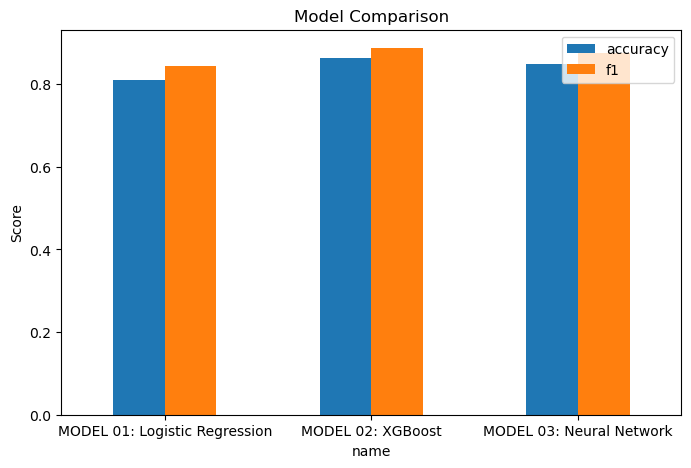

In [100]:
results = [lr_results, xgb_results, mlp_results]

summary = pd.DataFrame(results)[["name", "accuracy", "precision", "recall", "f1"]]

# print table
print(summary)

# create bar chart
summary.set_index("name")[["accuracy", "f1"]].plot(kind="bar", figsize=(8,5))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

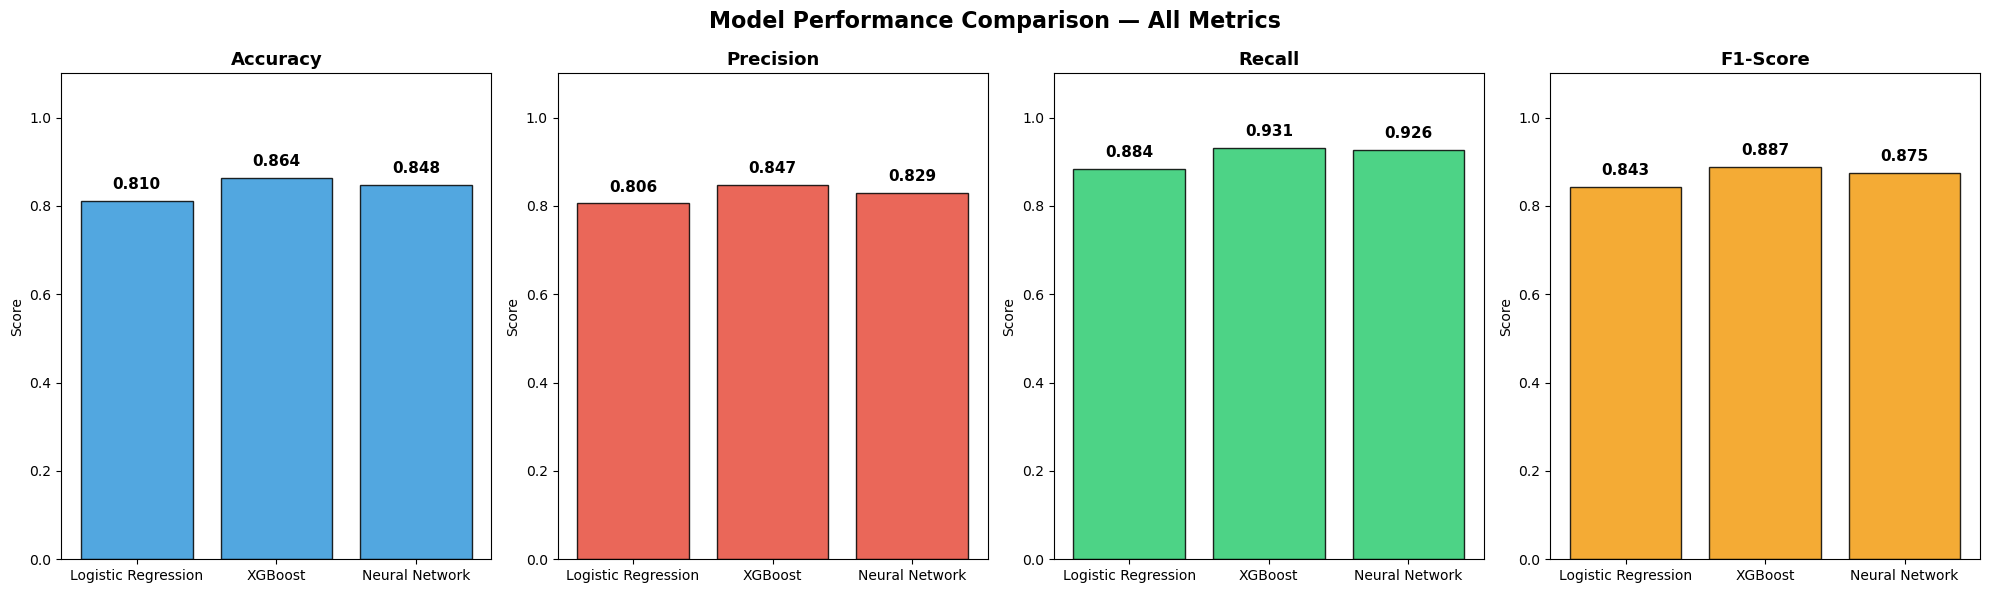

In [101]:
all_results   = [lr_results, xgb_results, mlp_results]
model_names   = [r['name'].split(': ')[1] for r in all_results]
metrics       = ['accuracy', 'precision', 'recall', 'f1']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors        = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
 
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Model Performance Comparison — All Metrics', fontsize=16, fontweight='bold')
 
for i, (metric, label, color) in enumerate(zip(metrics, metric_labels, colors)):
    values = [r[metric] for r in all_results]
    bars = axes[i].bar(model_names, values, color=color, alpha=0.85, edgecolor='black')
    axes[i].set_title(label, fontsize=13, fontweight='bold')
    axes[i].set_ylim(0, 1.1)
    axes[i].set_ylabel('Score')
    axes[i].tick_params(axis='x')
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
 
plt.tight_layout()
plt.show()

### Section 17: Visualization - Confusion Matrices

A confusion matrix shows the breakdown of correct and incorrect predictions for each model:

|  | Predicted Fail | Predicted Pass |
|--|----------------|----------------|
| **Actual Fail** | TN — correctly predicted Fail | FP — predicted Pass, actually Fail |
| **Actual Pass** | FN — predicted Fail, actually Pass | TP — correctly predicted Pass |

Strong models have large values along the diagonal (TN and TP). Off-diagonal values represent misclassifications.

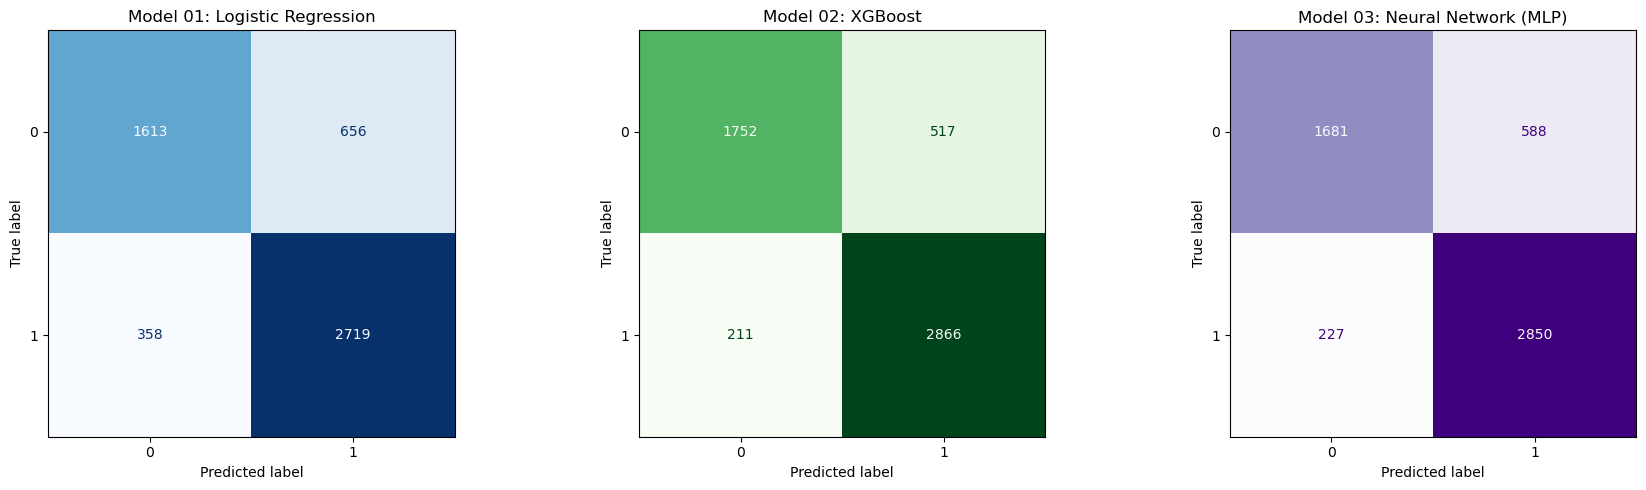

In [102]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# create 3 plots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Model 01: Logistic Regression (USE SCALED)
ConfusionMatrixDisplay.from_estimator(
    lr_model,
    X_test_scaled,
    y_test,
    ax=axes[0],
    cmap='Blues',
    colorbar=False
)
axes[0].set_title("Model 01: Logistic Regression")

# Model 02: XGBoost (USE RAW DATA)
ConfusionMatrixDisplay.from_estimator(
    xgb_model,
    X_test,
    y_test,
    ax=axes[1],
    cmap='Greens',
    colorbar=False
)
axes[1].set_title("Model 02: XGBoost")

# Model 03: Neural Network (USE SCALED)
ConfusionMatrixDisplay.from_estimator(
    mlp_model,
    X_test_scaled,
    y_test,
    ax=axes[2],
    cmap='Purples',
    colorbar=False
)
axes[2].set_title("Model 03: Neural Network (MLP)")

plt.tight_layout()
plt.show()

### Section 18: Visualization - XGBoost Feature Importance

XGBoost records how frequently each feature is used as a split condition across all trees. Features used more often have a higher importance score, indicating they contributed more to reducing prediction error during training. The top 15 most important features are shown below.

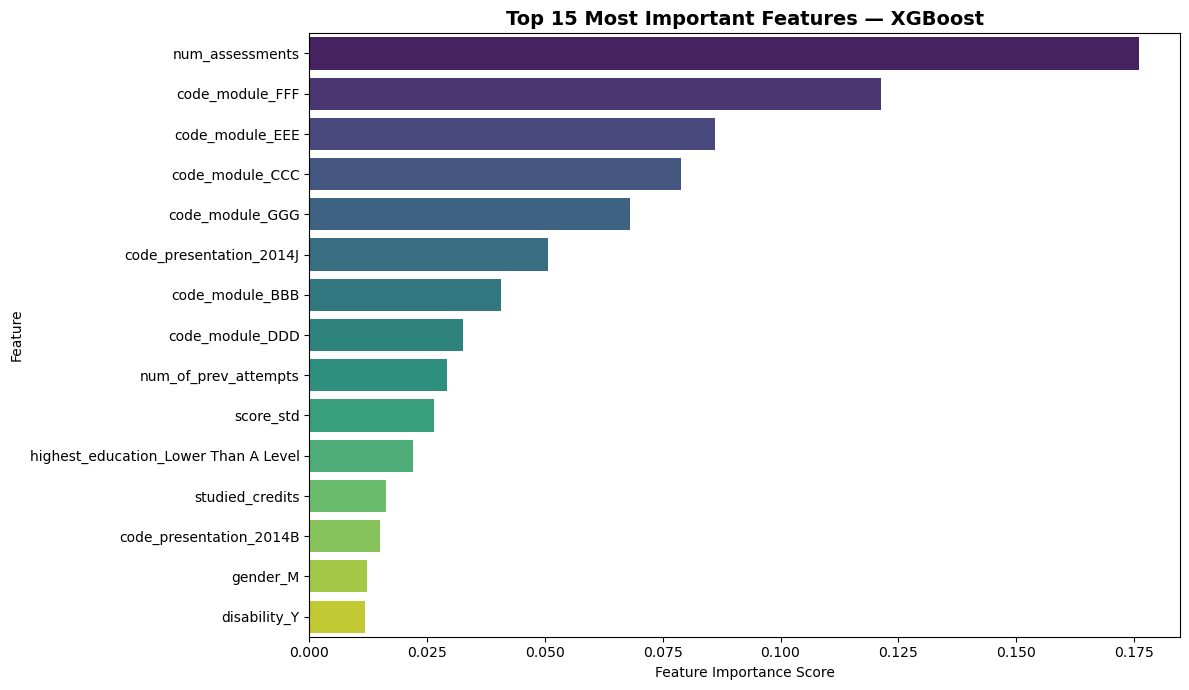

In [103]:
importances   = xgb_model.feature_importances_
feature_names = X.columns
 
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(15)
 
plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=feat_df, palette='viridis', hue='feature')
plt.title('Top 15 Most Important Features — XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Section 19: Final Results Summary

All three models are compared in a single table across all four metrics. The best model is identified by F1-Score, which balances precision and recall and is the primary metric used in this study.

In [104]:
print("FINAL RESULTS SUMMARY")

print(f"\n{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")

for r in all_results:
    name = r['name'].split(': ')[1]
    print(f"{name:<25} {r['accuracy']:>10.4f} {r['precision']:>10.4f} "
          f"{r['recall']:>10.4f} {r['f1']:>10.4f}")

best = max(all_results, key=lambda x: x['f1'])
best_name = best['name'].split(': ')[1]
print(f"\nBest model by F1-Score: {best_name} (F1 = {best['f1']:.4f})")

FINAL RESULTS SUMMARY

Model                       Accuracy  Precision     Recall         F1
Logistic Regression           0.8103     0.8056     0.8837     0.8428
XGBoost                       0.8638     0.8472     0.9314     0.8873
Neural Network                0.8475     0.8290     0.9262     0.8749

Best model by F1-Score: XGBoost (F1 = 0.8873)
